# MediMap AI — Data Exploration, Cleaning & Preprocessing

**Goal:** Prepare the Kaggle Disease-Symptom dataset for training a multi-class disease classifier.

**Input :** `data/raw/tabular/dataset.csv`  
**Outputs:** `data/processed/symptom_columns.json` — symptom vocabulary used at inference  
            `models/saved/label_encoder.pkl`      — disease label ↔ index mapping  

**Prediction task:** Given a binary symptom presence vector → predict disease class  

---
### ⚠️ Feature Leakage Warning
We use **only** the symptom columns as features. We do **NOT** use:
- Disease descriptions (text leakage)
- Symptom severity weights (future data — not available at prediction time)
- Symptom precautions (post-diagnosis information)

## 0 — Imports & Setup

In [3]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path('.').resolve()
RAW_CSV     = ROOT / 'data' / 'raw' / 'tabular' / 'dataset.csv'
PROC_DIR    = ROOT / 'data' / 'processed'
MODELS_DIR  = ROOT / 'models' / 'saved'
PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dataset path : {RAW_CSV}')
print(f'File exists  : {RAW_CSV.exists()}')

Dataset path : C:\Users\musty\OneDrive\Desktop\final  year project\notebooks\data\raw\tabular\dataset.csv
File exists  : True


---
## 1 — Load Raw Data

In [4]:
df_raw = pd.read_csv(RAW_CSV)

print(f'Shape       : {df_raw.shape}  (rows × columns)')
print(f'Columns     : {df_raw.columns.tolist()}')
print()
df_raw.head(5)

Shape       : (4920, 18)  (rows × columns)
Columns     : ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']



,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


### 1.1 — Null Value Audit

In [6]:
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(1)

null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print('Columns with null values:')
print(null_df[null_df['Null Count'] > 0].to_string())
print()
print('Note: NaN in Symptom columns is EXPECTED — patients rarely have 17 symptoms.')

Columns with null values:
            Null Count  Null %
Symptom_4          348     7.1
Symptom_5         1206    24.5
Symptom_6         1986    40.4
Symptom_7         2652    53.9
Symptom_8         2976    60.5
Symptom_9         3228    65.6
Symptom_10        3408    69.3
Symptom_11        3726    75.7
Symptom_12        4176    84.9
Symptom_13        4416    89.8
Symptom_14        4614    93.8
Symptom_15        4680    95.1
Symptom_16        4728    96.1
Symptom_17        4848    98.5

Note: NaN in Symptom columns is EXPECTED — patients rarely have 17 symptoms.


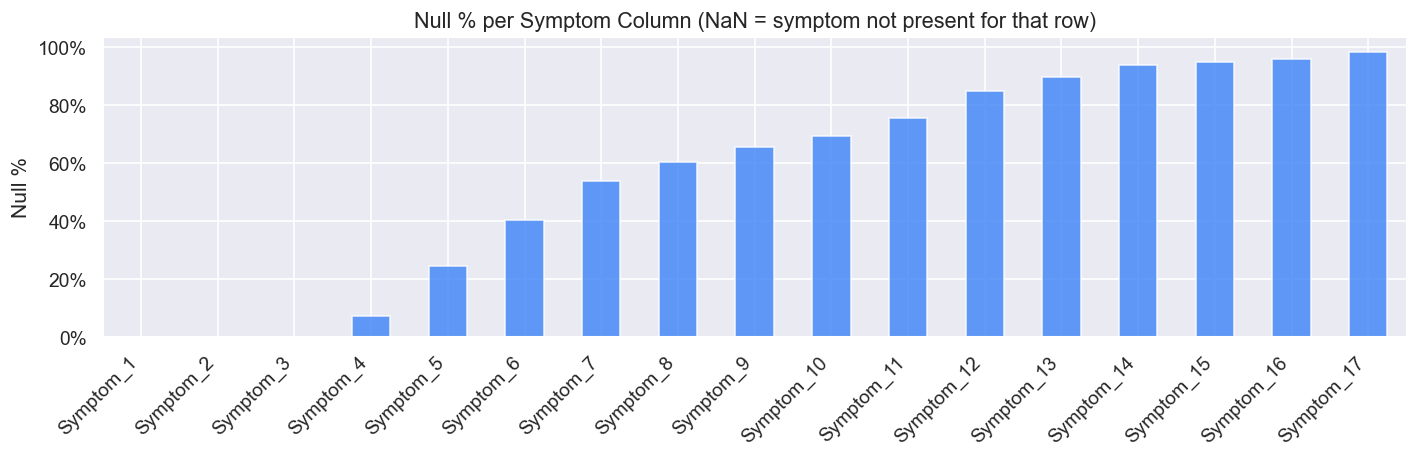

→ Higher null % in later symptom columns is normal (sparse dataset).


In [7]:
# Visualise null pattern
sym_null_pct = null_pct[[c for c in df_raw.columns if 'Symptom' in c]]

fig, ax = plt.subplots(figsize=(12, 4))
sym_null_pct.plot(kind='bar', ax=ax, color='#3b82f6', alpha=0.8)
ax.set_title('Null % per Symptom Column (NaN = symptom not present for that row)', fontsize=13)
ax.set_ylabel('Null %')
ax.set_xticklabels(sym_null_pct.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig(PROC_DIR / 'null_pattern.png', bbox_inches='tight')
plt.show()
print('→ Higher null % in later symptom columns is normal (sparse dataset).')

---
## 2 — Data Cleaning

In [8]:
df = df_raw.copy()

# ── Strip whitespace from column names ───────────────────────────────────────
df.columns = df.columns.str.strip()

# ── Strip and normalise the Disease column ────────────────────────────────────
df['Disease'] = df['Disease'].str.strip()

# ── Strip and lowercase ALL symptom columns ───────────────────────────────────
sym_cols = [c for c in df.columns if c.lower().startswith('symptom')]
for col in sym_cols:
    df[col] = df[col].str.strip().str.lower()

print(f'Symptom columns found : {len(sym_cols)}')
print(f'Symptom columns       : {sym_cols}')

Symptom columns found : 17
Symptom columns       : ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


In [9]:
# ── Check for duplicate rows ──────────────────────────────────────────────────
n_dups = df.duplicated().sum()
print(f'Duplicate rows        : {n_dups}')
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {n_dups} duplicates. New shape: {df.shape}')
else:
    print('No duplicates — dataset is clean.')

Duplicate rows        : 4616
Removed 4616 duplicates. New shape: (304, 18)


In [10]:
# ── Known typo corrections in symptom names ───────────────────────────────────
# These were found by inspecting unique symptom values across all columns
TYPO_MAP = {
    'dischromic _patches'  : 'dischromic_patches',
    'spotting_ urination'  : 'spotting_urination',
    'foul_smell_of urine'  : 'foul_smell_of_urine',
    'fluid_overload.1'     : 'fluid_overload',
}

for col in sym_cols:
    df[col] = df[col].replace(TYPO_MAP)

# Show all unique symptoms after cleaning
all_symptoms_raw: set[str] = set()
for col in sym_cols:
    all_symptoms_raw.update(df[col].dropna().unique())
all_symptoms_raw.discard('')

print(f'Total unique symptoms after cleaning : {len(all_symptoms_raw)}')
print(f'\nSample symptoms:')
for s in sorted(all_symptoms_raw)[:20]:
    print(f'  {s}')

Total unique symptoms after cleaning : 131

Sample symptoms:
  abdominal_pain
  abnormal_menstruation
  acidity
  acute_liver_failure
  altered_sensorium
  anxiety
  back_pain
  belly_pain
  blackheads
  bladder_discomfort
  blister
  blood_in_sputum
  bloody_stool
  blurred_and_distorted_vision
  breathlessness
  brittle_nails
  bruising
  burning_micturition
  chest_pain
  chills


---
## 3 — Target Variable (Disease) Analysis

In [11]:
disease_counts = df['Disease'].value_counts()
print(f'Total diseases : {df["Disease"].nunique()}')
print(f'Total samples  : {len(df)}')
print(f'Samples/disease: {len(df) / df["Disease"].nunique():.1f} (average)')
print()
print(disease_counts.to_string())

Total diseases : 41
Total samples  : 304
Samples/disease: 7.4 (average)

Disease
Migraine                                   10
Dengue                                     10
Hepatitis D                                10
Chicken pox                                10
Typhoid                                     9
Hepatitis B                                 9
Jaundice                                    9
hepatitis A                                 9
Diabetes                                    9
Hepatitis E                                 9
Pneumonia                                   9
Common Cold                                 9
Hypoglycemia                                9
Hyperthyroidism                             9
Tuberculosis                                9
Alcoholic hepatitis                         8
Chronic cholestasis                         8
Varicose veins                              8
Hypothyroidism                              8
Malaria                                     8

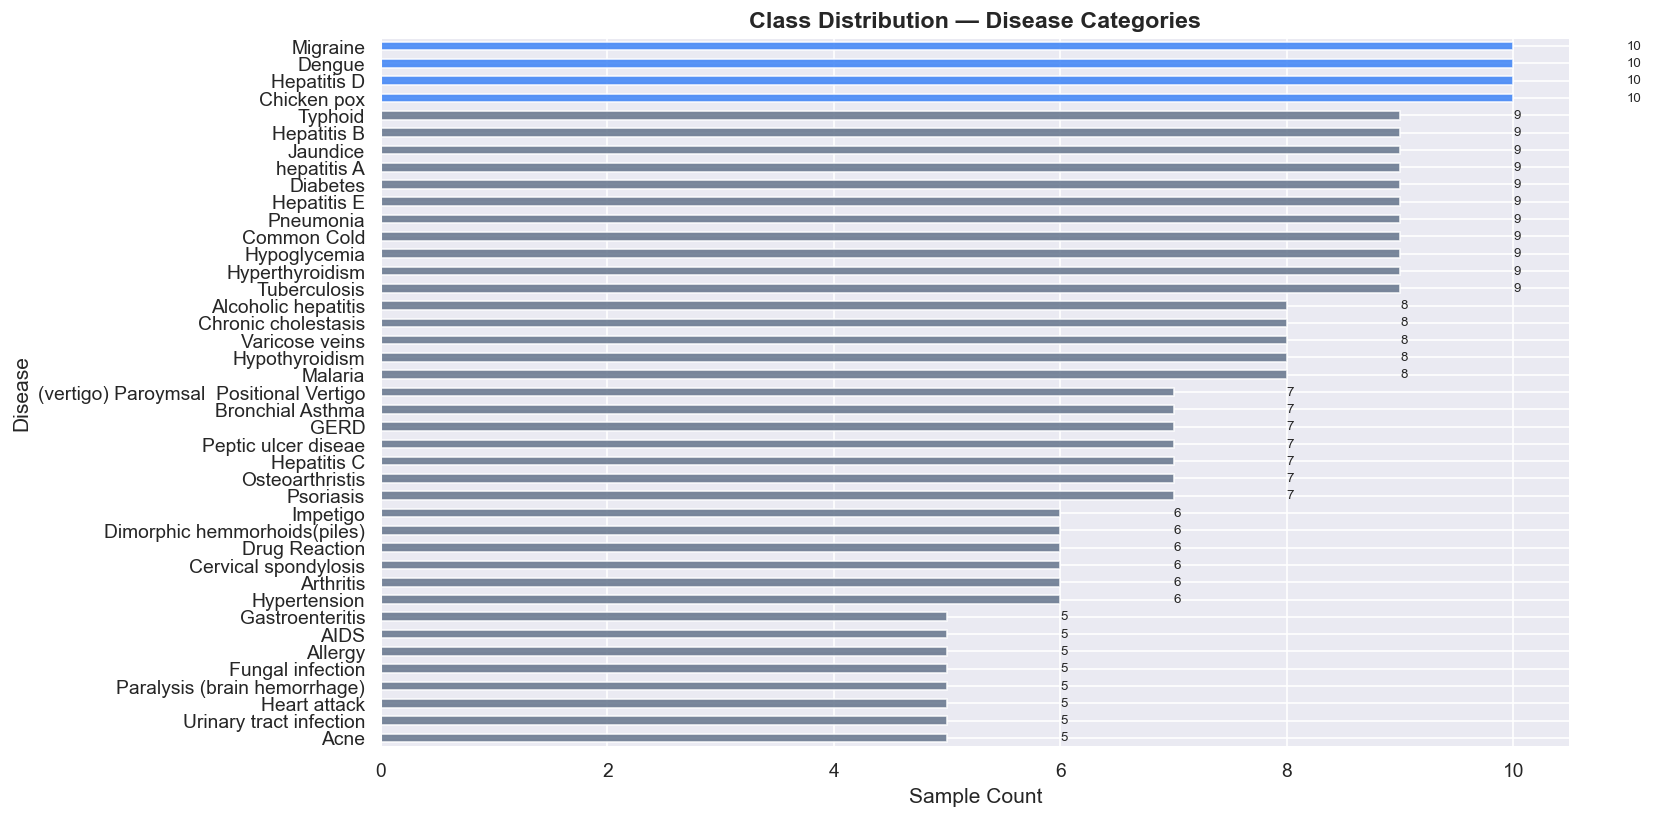

Max class  : Migraine (10 samples)
Min class  : Gastroenteritis (5 samples)
Imbalance  : 2.0x  ← <5x is acceptable for this task


In [12]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#3b82f6' if c == disease_counts.max() else '#64748b' for c in disease_counts.values]
disease_counts.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Class Distribution — Disease Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Count')
ax.invert_yaxis()
for i, v in enumerate(disease_counts.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(PROC_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()

imbalance_ratio = disease_counts.max() / disease_counts.min()
print(f'Max class  : {disease_counts.idxmax()} ({disease_counts.max()} samples)')
print(f'Min class  : {disease_counts.idxmin()} ({disease_counts.min()} samples)')
print(f'Imbalance  : {imbalance_ratio:.1f}x  ← <5x is acceptable for this task')

---
## 4 — Feature Engineering: Binary Symptom Matrix

**Decision:** Convert sparse symptom columns → dense binary presence matrix

| Before | After |
|--------|-------|
| 17 symptom name columns (sparse, NaN-heavy) | 131 binary columns (1 = symptom present) |
| `Symptom_1 = 'fever'` | `fever = 1.0` |
| `Symptom_7 = NaN` | `cough = 0.0` |

**Why this is NOT leakage:** We only encode whether a symptom is present — this is information the patient provides at prediction time.

In [13]:
# ── Build sorted symptom vocabulary ──────────────────────────────────────────
symptom_vocab = sorted(all_symptoms_raw)
print(f'Symptom vocabulary size: {len(symptom_vocab)}')

# ── Build binary matrix ───────────────────────────────────────────────────────
X = pd.DataFrame(0.0, index=df.index, columns=symptom_vocab, dtype='float32')

for col in sym_cols:
    filled = df[col].dropna()
    for sym in symptom_vocab:
        mask = filled == sym
        X.loc[filled[mask].index, sym] = 1.0

print(f'Feature matrix shape : {X.shape}  (samples × symptoms)')
print(f'Non-zero entries     : {int(X.values.sum())}  ({X.values.mean()*100:.1f}% sparsity inversion)')
X.head(3)

Symptom vocabulary size: 131
Feature matrix shape : (304, 131)  (samples × symptoms)
Non-zero entries     : 2325  (5.8% sparsity inversion)


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


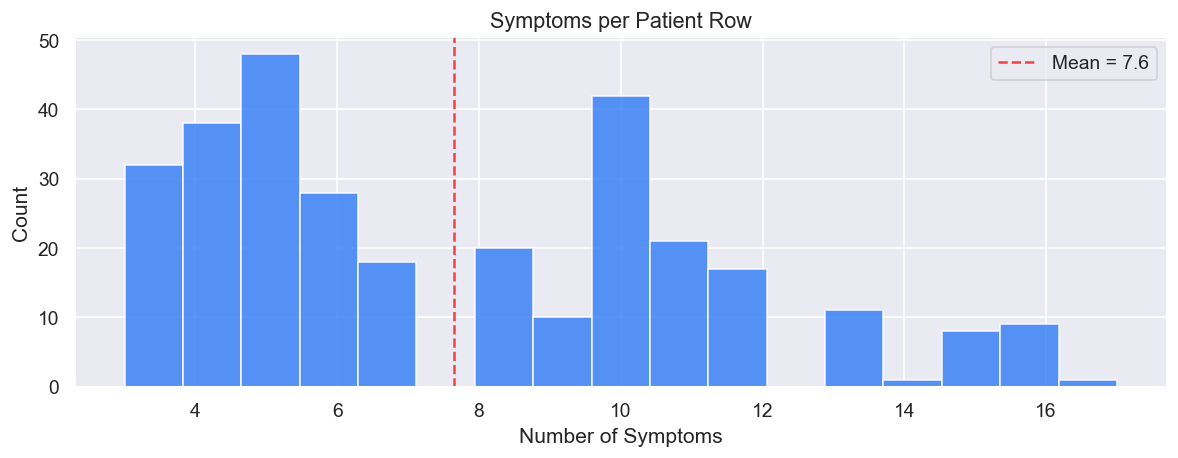

In [14]:
# ── Symptoms per row distribution ─────────────────────────────────────────────
symptoms_per_row = X.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
symptoms_per_row.plot(kind='hist', bins=17, ax=ax, color='#3b82f6', edgecolor='white', alpha=0.85)
ax.set_title('Symptoms per Patient Row', fontsize=13)
ax.set_xlabel('Number of Symptoms')
ax.set_ylabel('Count')
ax.axvline(symptoms_per_row.mean(), color='#ef4444', linestyle='--',
           label=f'Mean = {symptoms_per_row.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(PROC_DIR / 'symptoms_per_row.png', bbox_inches='tight')
plt.show()

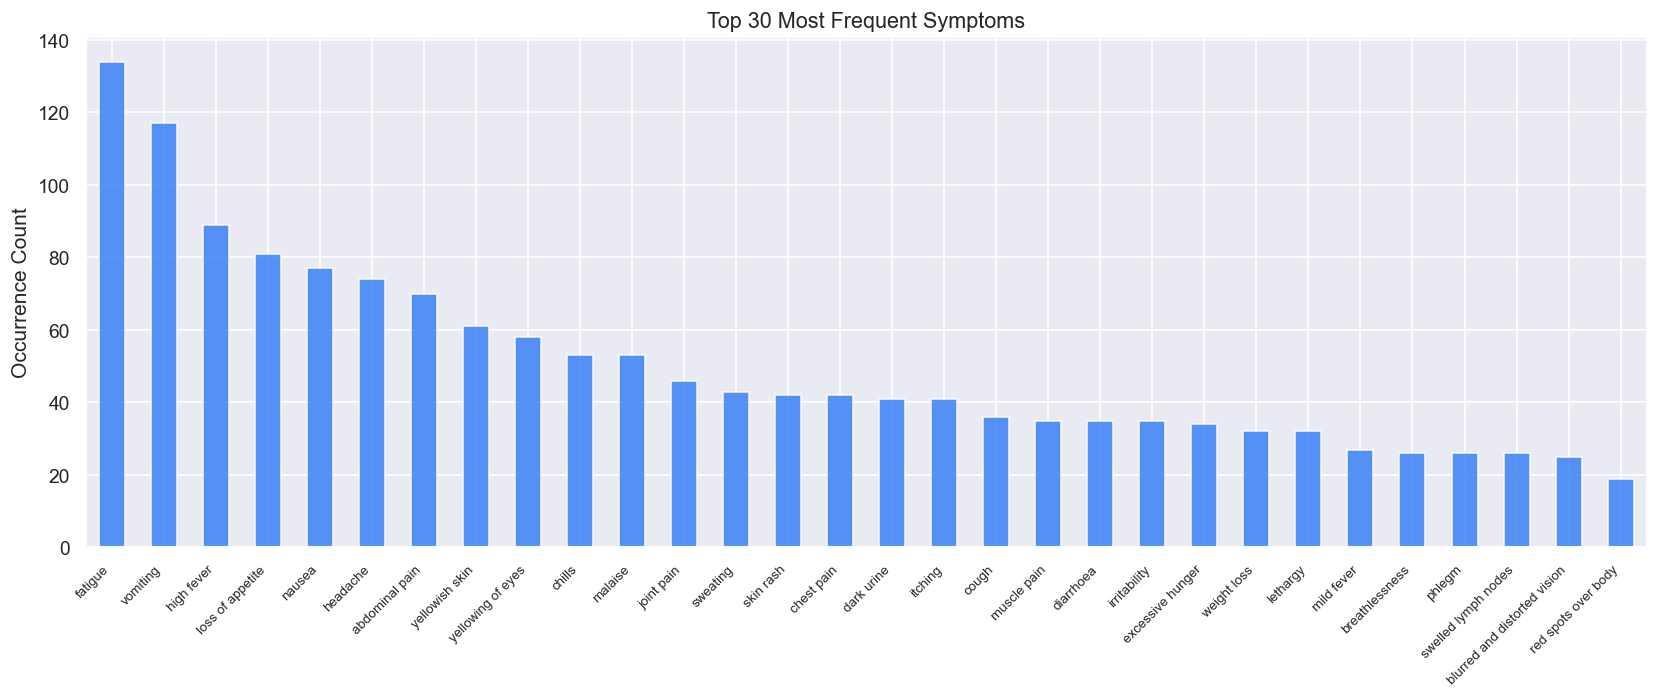

In [15]:
# ── Top 30 most common symptoms ───────────────────────────────────────────────
sym_freq = X.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sym_freq.head(30).plot(kind='bar', ax=ax, color='#3b82f6', alpha=0.85)
ax.set_title('Top 30 Most Frequent Symptoms', fontsize=13)
ax.set_ylabel('Occurrence Count')
ax.set_xticklabels([s.replace('_', ' ') for s in sym_freq.head(30).index],
                   rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(PROC_DIR / 'top_symptoms.png', bbox_inches='tight')
plt.show()

In [16]:
# ── Check for zero-variance features (symptoms that never appear) ─────────────
zero_var = sym_freq[sym_freq == 0]
print(f'Zero-variance symptoms (never appear): {len(zero_var)}')
if len(zero_var) > 0:
    print('Removing them — they add no information:')
    print(zero_var.index.tolist())
    X = X.drop(columns=zero_var.index.tolist())
    symptom_vocab = [s for s in symptom_vocab if s not in zero_var.index]
    print(f'New feature matrix shape: {X.shape}')
else:
    print('All symptoms appear at least once — no features removed.')

Zero-variance symptoms (never appear): 0
All symptoms appear at least once — no features removed.


---
## 5 — Label Encoding

In [17]:
le = LabelEncoder()
y  = le.fit_transform(df['Disease'])

print(f'Classes : {len(le.classes_)}')
print()
for idx, name in enumerate(le.classes_):
    count = (y == idx).sum()
    print(f'  [{idx:2d}] {name:45s} — {count} samples')

Classes : 41

  [ 0] (vertigo) Paroymsal  Positional Vertigo       — 7 samples
  [ 1] AIDS                                          — 5 samples
  [ 2] Acne                                          — 5 samples
  [ 3] Alcoholic hepatitis                           — 8 samples
  [ 4] Allergy                                       — 5 samples
  [ 5] Arthritis                                     — 6 samples
  [ 6] Bronchial Asthma                              — 7 samples
  [ 7] Cervical spondylosis                          — 6 samples
  [ 8] Chicken pox                                   — 10 samples
  [ 9] Chronic cholestasis                           — 8 samples
  [10] Common Cold                                   — 9 samples
  [11] Dengue                                        — 10 samples
  [12] Diabetes                                      — 9 samples
  [13] Dimorphic hemmorhoids(piles)                  — 6 samples
  [14] Drug Reaction                                 — 6 samples
  [15] Fu

---
## 6 — Train / Validation Split

In [18]:
X_np = X.values.astype('float32')

X_train, X_val, y_train, y_val = train_test_split(
    X_np, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class proportions in both splits
)

print(f'Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X_np)*100:.0f}%)')
print(f'Validation set : {X_val.shape[0]} samples  ({X_val.shape[0]/len(X_np)*100:.0f}%)')
print(f'Feature dim    : {X_train.shape[1]} symptoms')
print(f'Classes        : {len(le.classes_)}')

Training set   : 243 samples  (80%)
Validation set : 61 samples  (20%)
Feature dim    : 131 symptoms
Classes        : 41


In [19]:
# Verify stratification: check class proportions are similar in train vs val
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
val_dist   = pd.Series(y_val  ).value_counts(normalize=True).sort_index()

split_check = pd.DataFrame({
    'Disease'     : le.classes_,
    'Train %'     : (train_dist.values * 100).round(2),
    'Val %'       : (val_dist.values   * 100).round(2),
})
split_check['Drift (pp)'] = (split_check['Train %'] - split_check['Val %']).abs().round(2)
print('Stratification check (drift should be < 1 percentage point):')
print(split_check.to_string(index=False))

Stratification check (drift should be < 1 percentage point):
                                Disease  Train %  Val %  Drift (pp)
(vertigo) Paroymsal  Positional Vertigo     2.47   1.64        0.83
                                   AIDS     1.65   1.64        0.01
                                   Acne     1.65   1.64        0.01
                    Alcoholic hepatitis     2.47   3.28        0.81
                                Allergy     1.65   1.64        0.01
                              Arthritis     2.06   1.64        0.42
                       Bronchial Asthma     2.47   1.64        0.83
                   Cervical spondylosis     2.06   1.64        0.42
                            Chicken pox     3.29   3.28        0.01
                    Chronic cholestasis     2.47   3.28        0.81
                            Common Cold     2.88   3.28        0.40
                                 Dengue     3.29   3.28        0.01
                               Diabetes     2.88   3.28

---
## 7 — Correlation Heatmap (Top Features × Top Diseases)

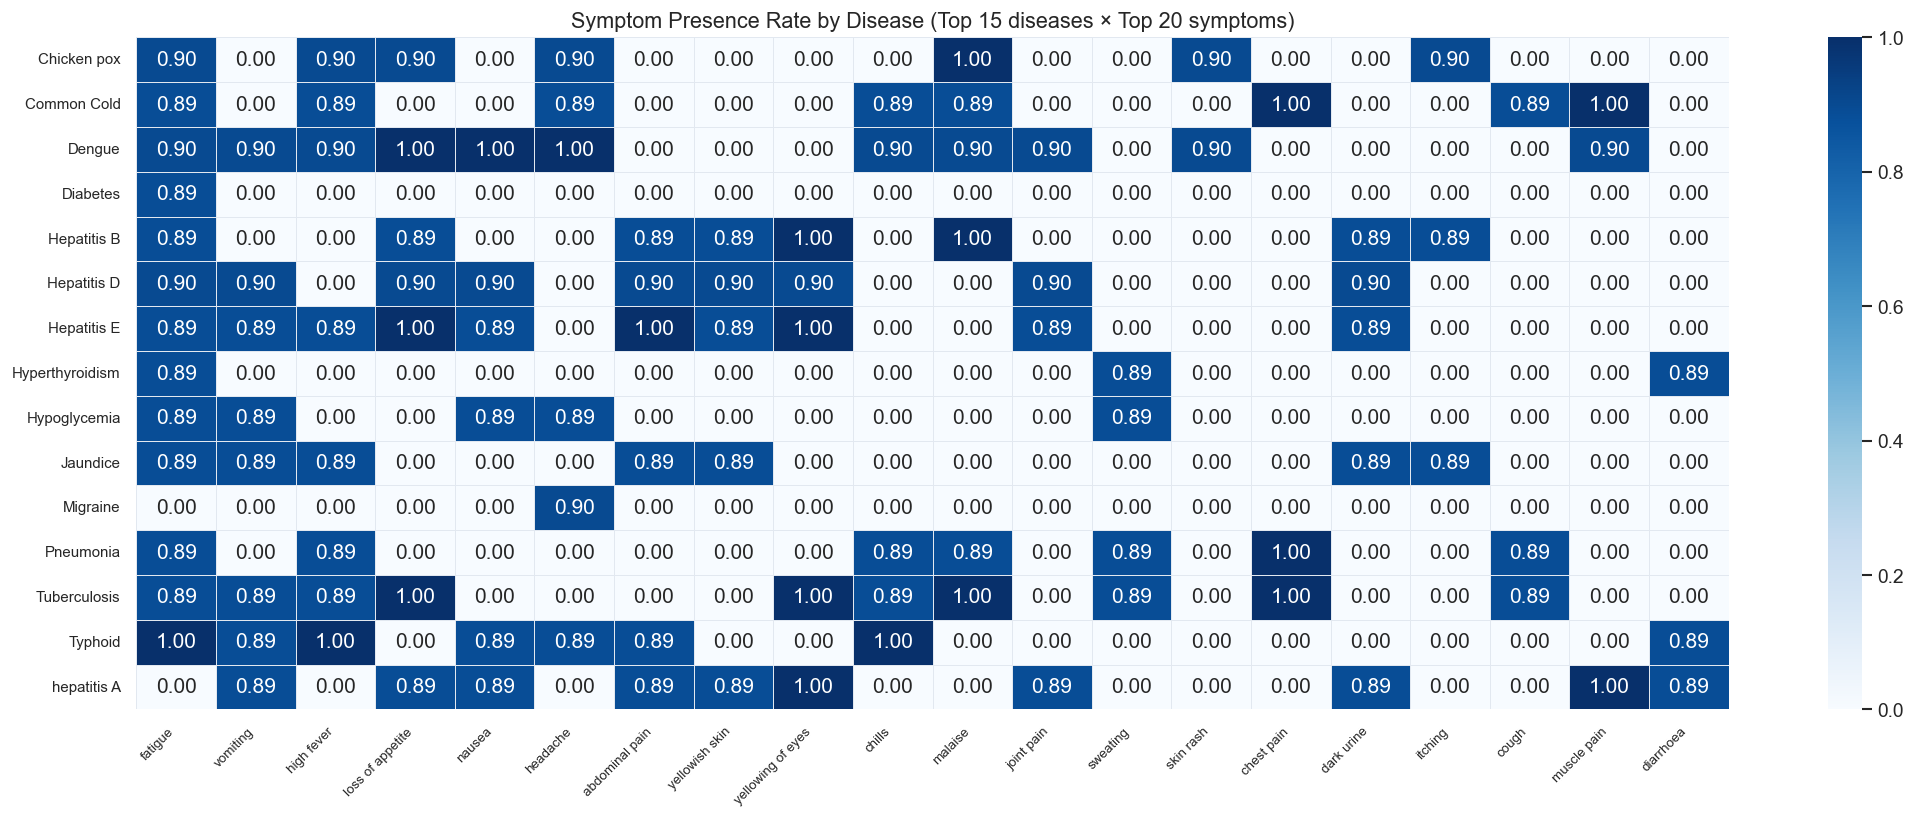

In [20]:
# Compute mean symptom presence per disease class
Xdf = X.copy()
Xdf['disease_idx'] = y
Xdf['Disease']     = df['Disease'].values

top_diseases = disease_counts.head(15).index.tolist()
top_symptoms = sym_freq.head(20).index.tolist()

heat_data = (
    Xdf[Xdf['Disease'].isin(top_diseases)]
    .groupby('Disease')[top_symptoms]
    .mean()
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    heat_data,
    cmap='Blues', annot=True, fmt='.2f',
    linewidths=0.5, linecolor='#e2e8f0',
    xticklabels=[s.replace('_', ' ') for s in top_symptoms],
    ax=ax,
)
ax.set_title('Symptom Presence Rate by Disease (Top 15 diseases × Top 20 symptoms)', fontsize=13)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR / 'symptom_disease_heatmap.png', bbox_inches='tight')
plt.show()

---
## 8 — Save Processed Artifacts

In [21]:
# ── 8.1  Symptom vocabulary (used by the app at inference time) ───────────────
sym_col_path = PROC_DIR / 'symptom_columns.json'
with open(sym_col_path, 'w') as fh:
    json.dump(symptom_vocab, fh, indent=2)
print(f'✅ Symptom columns saved → {sym_col_path}  ({len(symptom_vocab)} features)')

✅ Symptom columns saved → C:\Users\musty\OneDrive\Desktop\final  year project\notebooks\data\processed\symptom_columns.json  (131 features)


In [22]:
# ── 8.2  Label encoder ────────────────────────────────────────────────────────
le_path = MODELS_DIR / 'label_encoder.pkl'
joblib.dump(le, le_path)
print(f'✅ Label encoder saved  → {le_path}  ({len(le.classes_)} classes)')

✅ Label encoder saved  → C:\Users\musty\OneDrive\Desktop\final  year project\notebooks\models\saved\label_encoder.pkl  (41 classes)


In [23]:
# ── 8.3  Processed splits (optional — train.py re-creates these, but saves time) 
splits_dir = PROC_DIR / 'splits'
splits_dir.mkdir(exist_ok=True)
np.save(splits_dir / 'X_train.npy', X_train)
np.save(splits_dir / 'X_val.npy',   X_val)
np.save(splits_dir / 'y_train.npy', y_train)
np.save(splits_dir / 'y_val.npy',   y_val)
print(f'✅ Splits saved → {splits_dir}')
print(f'   X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'   X_val  : {X_val.shape}    y_val  : {y_val.shape}')

✅ Splits saved → C:\Users\musty\OneDrive\Desktop\final  year project\notebooks\data\processed\splits
   X_train: (243, 131)  y_train: (243,)
   X_val  : (61, 131)    y_val  : (61,)


---
## 9 — Summary & Next Steps

In [24]:
print('=' * 55)
print('  MediMap AI — Dataset Summary')
print('=' * 55)
print(f'  Raw samples          : {len(df_raw)}')
print(f'  After deduplication  : {len(df)}')
print(f'  Feature dimensions   : {X.shape[1]} symptom columns')
print(f'  Target classes       : {len(le.classes_)} diseases')
print(f'  Training samples     : {len(X_train)}')
print(f'  Validation samples   : {len(X_val)}')
print(f'  Class imbalance      : {imbalance_ratio:.1f}x (acceptable)')
print('=' * 55)
print()
print('Artifacts written:')
print(f'  data/processed/symptom_columns.json')
print(f'  data/processed/splits/X_train.npy')
print(f'  data/processed/splits/X_val.npy')
print(f'  data/processed/splits/y_train.npy')
print(f'  data/processed/splits/y_val.npy')
print(f'  models/saved/label_encoder.pkl')
print()
print('Next step: Run training')
print('  python models/train.py --tabular_csv data/raw/tabular/dataset.csv --epochs 30 --batch_size 64')

  MediMap AI — Dataset Summary
  Raw samples          : 4920
  After deduplication  : 304
  Feature dimensions   : 131 symptom columns
  Target classes       : 41 diseases
  Training samples     : 243
  Validation samples   : 61
  Class imbalance      : 2.0x (acceptable)

Artifacts written:
  data/processed/symptom_columns.json
  data/processed/splits/X_train.npy
  data/processed/splits/X_val.npy
  data/processed/splits/y_train.npy
  data/processed/splits/y_val.npy
  models/saved/label_encoder.pkl

Next step: Run training
  python models/train.py --tabular_csv data/raw/tabular/dataset.csv --epochs 30 --batch_size 64
